In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append("../Environment")
import photod
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
test_path="../data/BayesMethod3D_SDSSpatchRA340-350_KarloTest_NN.txt"

In [4]:
sims = pd.read_table(test_path,delim_whitespace=True)
sims

,gLon,gLat,ArSFD,umag,gmag,rmag,imag,zmag,uerr,gerr,...,ugerr,grerr,rierr,izerr,MrNN,MrNNUnc,ArNN,ArNNUnc,FeHNN,FeHNNUnc
0,66.502595,-49.417407,0.14,27.721,24.965,23.44,22.257,21.598,1.230,0.037,...,1.230556,0.038897,0.014422,0.012042,10.520563,0.185664,0.304853,0.030698,-0.772777,0.042766
1,66.485297,-49.395984,0.15,20.991,18.334,16.94,16.276,15.892,0.008,0.005,...,0.009434,0.007071,0.007071,0.007071,8.367607,0.324536,0.132328,0.034813,-0.431198,0.120609
2,66.487646,-49.404677,0.16,22.724,21.267,20.55,20.273,20.136,0.017,0.006,...,0.018028,0.007810,0.007071,0.007810,6.721160,0.000674,0.160674,0.013041,-1.625147,0.125545
3,66.489872,-49.401734,0.14,26.367,23.511,22.07,20.636,19.877,0.355,0.012,...,0.355203,0.013892,0.009220,0.008485,11.319904,0.154330,0.121943,0.014958,-0.254383,0.143858
4,66.493965,-49.402138,0.18,25.480,22.636,21.25,20.620,20.271,0.159,0.008,...,0.159201,0.010000,0.008485,0.008485,8.252782,0.100802,0.206959,0.001052,-0.593690,0.063806
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
617768,81.272992,-53.801461,0.16,25.318,24.224,23.64,23.357,23.267,0.139,0.020,...,0.140431,0.023854,0.020616,0.029682,6.045439,0.216045,0.245260,0.028282,-1.723153,0.007367
617769,81.416632,-53.800164,0.13,26.604,25.858,25.93,26.111,26.289,0.442,0.081,...,0.449361,0.117414,0.183831,0.400656,3.362709,0.479863,-0.110317,0.064837,-1.764993,0.216966
617770,81.304959,-53.917593,0.16,24.746,23.984,23.67,23.545,23.575,0.084,0.017,...,0.085703,0.022023,0.022804,0.037590,4.598833,0.069268,0.071230,0.002319,-1.971615,0.012950
617771,81.310707,-53.915928,0.16,26.409,25.240,24.66,24.413,24.328,0.368,0.047,...,0.370989,0.054708,0.045607,0.071694,6.103991,0.059733,0.198011,0.041081,-1.641903,0.002085


In [8]:
Ar_B_Unc = sims["ArUnc"].values
Mr_B_Unc = sims["MrUnc"].values
Feh_B_Unc = sims["FeHUnc"].values
Ar_NN_Unc= sims["ArNNUnc"].values
Mr_NN_Unc = sims["MrNNUnc"].values
Feh_NN_Unc = sims["FeHNNUnc"].values

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


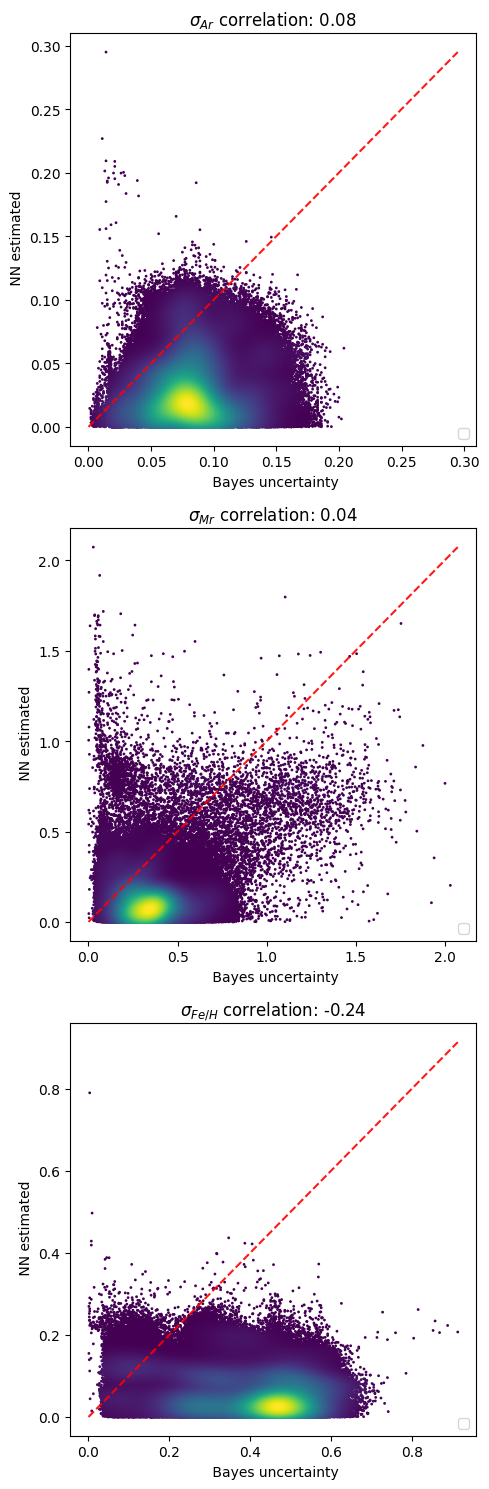

In [10]:
corr_Ar = str(round(np.corrcoef(Ar_B_Unc, Ar_NN_Unc)[0, 1], 2))
corr_Mr = str(round(np.corrcoef(Mr_B_Unc, Mr_NN_Unc)[0, 1], 2))
corr_Feh = str(round(np.corrcoef(Feh_B_Unc, Feh_NN_Unc)[0, 1], 2))
fig, ax = plt.subplots(3, figsize=(5, 3 * 5))
ax[0] = photod.plot_tools.plot_correlation(Ar_B_Unc, Ar_NN_Unc, ax[0], small_size=200, true_name="Bayes uncertainty")
ax[0].set_title(r"$\sigma_{Ar}$ correlation: "+corr_Ar)
ax[1] = photod.plot_tools.plot_correlation(Mr_B_Unc, Mr_NN_Unc, ax[1], small_size=200, true_name="Bayes uncertainty")
ax[1].set_title(r"$\sigma_{Mr}$ correlation: "+corr_Mr)
ax[2]=photod.plot_tools.plot_correlation(Feh_B_Unc, Feh_NN_Unc, ax[2], small_size=200, true_name="Bayes uncertainty")
ax[2].set_title(r"$\sigma_{Fe/H}$ correlation: "+corr_Feh)
fig.tight_layout()

In [19]:
fig.savefig("../outputs/sigma_correlation.png")

In [12]:
Ar_B_Unc = sims["ArUnc"].values
Mr_B_Unc = sims["MrUnc"].values
Feh_B_Unc = sims["FeHUnc"].values
Ar_B_Est= sims["ArEst"].values
Mr_B_Est = sims["MrEst"].values
Feh_B_Est = sims["FeHEst"].values

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


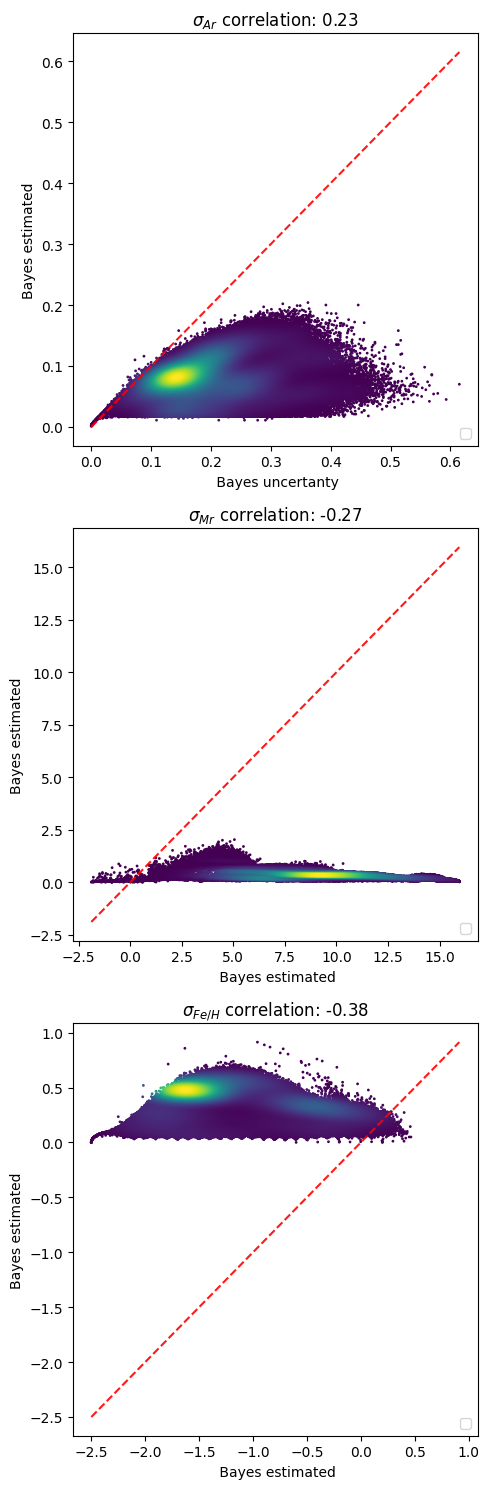

In [15]:
corr_Ar = str(round(np.corrcoef(Ar_B_Unc, Ar_B_Est)[0, 1], 2))
corr_Mr = str(round(np.corrcoef(Mr_B_Unc, Mr_B_Est)[0, 1], 2))
corr_Feh = str(round(np.corrcoef(Feh_B_Unc, Feh_B_Est)[0, 1], 2))
fig, ax = plt.subplots(3, figsize=(5, 3 * 5))
ax[0] = photod.plot_tools.plot_correlation(Ar_B_Est, Ar_B_Unc, ax[0], small_size=200, true_name="Bayes uncertanty")
ax[0].set_ylabel("Bayes estimated")
ax[0].set_title(r"$\sigma_{Ar}$ correlation: "+corr_Ar)
ax[1] = photod.plot_tools.plot_correlation(Mr_B_Est,Mr_B_Unc,  ax[1], small_size=200, true_name="Bayes estimated")
ax[1].set_ylabel("Bayes estimated")
ax[1].set_title(r"$\sigma_{Mr}$ correlation: "+corr_Mr)
ax[2]=photod.plot_tools.plot_correlation(Feh_B_Est, Feh_B_Unc, ax[2], small_size=200, true_name="Bayes estimated")
ax[2].set_ylabel("Bayes estimated")
ax[2].set_title(r"$\sigma_{Fe/H}$ correlation: "+corr_Feh)
fig.tight_layout()

In [24]:
Ar_B_Unc = sims["ArUnc"].values
Mr_B_Unc = sims["MrUnc"].values
Feh_B_Unc = sims["FeHUnc"].values
r_err= sims["rerr"].values

In [ ]:
corr_Ar = str(round(np.corrcoef(Ar_B_Unc, r_err)[0, 1], 2))
corr_Mr = str(round(np.corrcoef(Mr_B_Unc, r_err)[0, 1], 2))
corr_Feh = str(round(np.corrcoef(Feh_B_Unc, r_err)[0, 1], 2))
fig, ax = plt.subplots(3, figsize=(5, 3 * 5))
ax[0] = photod.plot_tools.plot_correlation(r_err, Ar_B_Unc, ax[0], small_size=200, true_name="Bayes uncertanty")
ax[0].set_ylabel("r err")
ax[0].set_title(r"$\sigma_{Ar}$ correlation: "+corr_Ar)
ax[1] = photod.plot_tools.plot_correlation(r_err,Mr_B_Unc,  ax[1], small_size=200, true_name="Bayes estimated")
ax[1].set_ylabel("r err")
ax[1].set_title(r"$\sigma_{Mr}$ correlation: "+corr_Mr)
ax[2]=photod.plot_tools.plot_correlation(r_err, Feh_B_Unc, ax[2], small_size=200, true_name="Bayes estimated")
ax[2].set_ylabel("r err")
ax[2].set_title(r"$\sigma_{Fe/H}$ correlation: "+corr_Feh)
fig.tight_layout()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


In [22]:
Ar_B_Unc = sims["ArUnc"].values
Mr_B_Unc = sims["MrUnc"].values
Feh_B_Unc = sims["FeHUnc"].values
for filter in ["r", "ug", "gr", "ri", "iz"]:
    r_err= sims[filter+"err"].values
    corr_Ar = str(round(np.corrcoef(Ar_B_Unc, r_err)[0, 1], 2))
    corr_Mr = str(round(np.corrcoef(Mr_B_Unc, r_err)[0, 1], 2))
    corr_Feh = str(round(np.corrcoef(Feh_B_Unc, r_err)[0, 1], 2))
    print (filter," Ar:"+corr_Ar, "Mr:"+corr_Mr, "Feh:"+corr_Feh)

r  Ar:0.54 Mr:0.54 Feh:0.45
ug  Ar:0.49 Mr:0.2 Feh:0.41
gr  Ar:0.5 Mr:0.34 Feh:0.4
ri  Ar:0.53 Mr:0.63 Feh:0.44
iz  Ar:0.43 Mr:0.69 Feh:0.37


In [23]:
Ar_B_Unc = sims["ArUnc"].values
Mr_B_Unc = sims["MrUnc"].values
Feh_B_Unc = sims["FeHUnc"].values
for filter in ["u", "g", "r", "i", "z"]:
    r_err= sims[filter+"err"].values
    corr_Ar = str(round(np.corrcoef(Ar_B_Unc, r_err)[0, 1], 2))
    corr_Mr = str(round(np.corrcoef(Mr_B_Unc, r_err)[0, 1], 2))
    corr_Feh = str(round(np.corrcoef(Feh_B_Unc, r_err)[0, 1], 2))
    print (filter," Ar:"+corr_Ar, "Mr:"+corr_Mr, "Feh:"+corr_Feh)

u  Ar:0.49 Mr:0.2 Feh:0.41
g  Ar:0.49 Mr:0.32 Feh:0.39
r  Ar:0.54 Mr:0.54 Feh:0.45
i  Ar:0.48 Mr:0.69 Feh:0.41
z  Ar:0.41 Mr:0.69 Feh:0.35
